Using dataset:Sleepy Driver EEG Brainwave Data
EEG data from sleepy and awake drivers


In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df = pd.read_csv('acquiredDataset.csv')


In [36]:
print(df.shape)

(3735, 11)


In [37]:
print(df.head())

   attention  meditation   delta   theta  lowAlpha  highAlpha  lowBeta  \
0         26          34  960462  277180     26575      27356    26575   
1         29          54   39145   28225     20172      39551    20172   
2         40          48   75410   43144      8601      13564     8601   
3         66          47   16057   41211      2534      34254     2534   
4         81          67   10304   47239     33158      47349    33158   

   highBeta  lowGamma  highGamma  classification  
0     13056      9126       2683               0  
1      9933      5237       4750               0  
2     11663      2515       3251               0  
3     27663     11396       2825               0  
4     16328      5298       5471               0  


In [38]:
print(df.columns.tolist())

['attention', 'meditation', 'delta', 'theta', 'lowAlpha', 'highAlpha', 'lowBeta', 'highBeta', 'lowGamma', 'highGamma', 'classification']


In [39]:

df = df.drop(columns=['attention', 'meditation'])



In [40]:

print(df['classification'].value_counts())


classification
0    2135
1    1600
Name: count, dtype: int64


In [41]:
print(df['classification'].value_counts(normalize=True) * 100)

classification
0    57.161981
1    42.838019
Name: proportion, dtype: float64


In [10]:
X = df.drop(columns=['classification'])
y = df['classification']

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [43]:
x_train.shape


(2988, 8)

In [44]:
x_test.shape

(747, 8)

In [45]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score



In [46]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)


In [47]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x_train, y_train)  # RF does nt need scaling
rf_preds = rf.predict(x_test)

In [50]:
print("=== Random Forest ===")

print(accuracy_score(y_test, rf_preds))


=== Random Forest ===
0.7697456492637216


In [51]:
print(classification_report(y_test, rf_preds))

              precision    recall  f1-score   support

           0       0.78      0.83      0.81       427
           1       0.76      0.68      0.72       320

    accuracy                           0.77       747
   macro avg       0.77      0.76      0.76       747
weighted avg       0.77      0.77      0.77       747



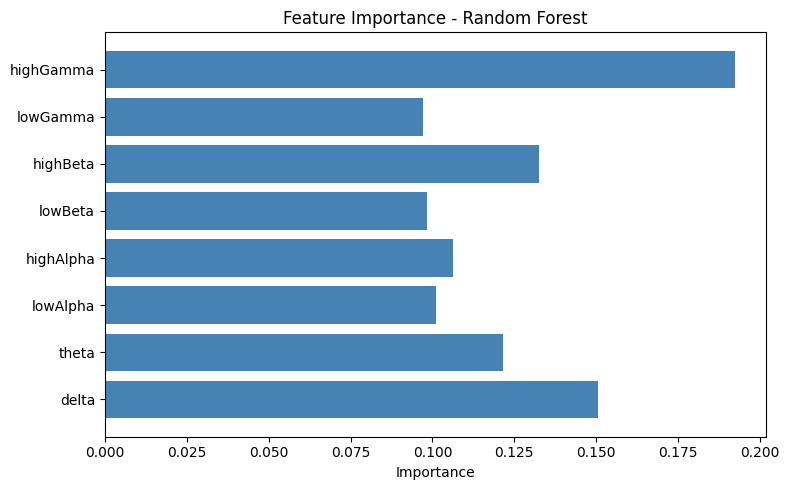

In [52]:
importances = rf.feature_importances_
features = X.columns

plt.figure(figsize=(8,5))
plt.barh(features, importances, color='steelblue')
plt.xlabel('Importance')
plt.title('Feature Importance - Random Forest')
plt.tight_layout()
plt.show()

In [63]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}


In [64]:
grid_search = GridSearchCV(RandomForestClassifier(random_state=42),
                           param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(x_train, y_train)


GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='accuracy')

In [65]:

print("Best params:", grid_search.best_params_)

Best params: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}


In [66]:
print("Best CV accuracy:", grid_search.best_score_)

Best CV accuracy: 0.7677462003439719


In [67]:

best_rf = grid_search.best_estimator_
print("Test accuracy:", accuracy_score(y_test, best_rf.predict(x_test)))


Test accuracy: 0.7724230254350736


In [53]:
#SVM

In [54]:
svm = SVC(kernel='rbf', random_state=42)
svm.fit(x_train_scaled, y_train)
svm_preds = svm.predict(x_test_scaled)

In [55]:
print("=== SVM ===")
print(accuracy_score(y_test, svm_preds))



=== SVM ===
0.6880856760374833


In [56]:
print(classification_report(y_test, svm_preds))

              precision    recall  f1-score   support

           0       0.74      0.69      0.72       427
           1       0.62      0.68      0.65       320

    accuracy                           0.69       747
   macro avg       0.68      0.69      0.68       747
weighted avg       0.69      0.69      0.69       747



In [58]:
#XGbOOst

In [60]:
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
xgb.fit(x_train, y_train)
xgb_preds = xgb.predict(x_test)



In [61]:
print("=== XGBoost ===")
print(accuracy_score(y_test, xgb_preds))


=== XGBoost ===
0.7630522088353414


In [62]:
print(classification_report(y_test, xgb_preds))

              precision    recall  f1-score   support

           0       0.78      0.81      0.80       427
           1       0.74      0.70      0.72       320

    accuracy                           0.76       747
   macro avg       0.76      0.75      0.76       747
weighted avg       0.76      0.76      0.76       747



The conclusion:
Random forest best perfomed but at 77% accuracy only, hyperparamter tuning didn't help ,maybe it is because the model has reached the limit with tabular features...
Moving on to Deep learning to caputer non-linearities.